In [46]:
#Importing libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              precision_score, recall_score, f1_score)
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv('output.csv')
df.head(1)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,age,trans_num,merch_lat,merch_long,is_fraud
0,5/8/2020 6:43:53 AM,213161293389774,"Schoen, Kuphal and Nitzsche",grocery_pos,48.31,F,74890 Rodriguez Springs Apt. 540,West Henrietta,NY,14586,43.0397,-77.6871,10256,"Teacher, primary school",6/24/1968,57,e1ab00d4df7634a8f97953a0a9d15884,43.011995,-76.873188,0


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  str    
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  str    
 3   category               1296675 non-null  str    
 4   amt                    1296675 non-null  float64
 5   gender                 1296675 non-null  str    
 6   street                 1296675 non-null  str    
 7   city                   1296675 non-null  str    
 8   state                  1296675 non-null  str    
 9   zip                    1296675 non-null  int64  
 10  lat                    1296675 non-null  float64
 11  long                   1296675 non-null  float64
 12  city_pop               1296675 non-null  int64  
 13  job                    1296675 non-null  str    
 14  dob                    129667

In [49]:
df.duplicated().any().sum()

np.int64(0)

In [50]:
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
age                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [51]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'age', 'trans_num', 'merch_lat', 'merch_long',
       'is_fraud'],
      dtype='str')

In [52]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,age,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,5.183060e+01,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.739295e+01,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,2.100000e+01,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,3.800000e+01,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,5.000000e+01,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,6.300000e+01,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.010000e+02,6.751027e+01,-6.695090e+01,1.000000e+00


In [53]:
df.describe(include = 'str')

,trans_date_trans_time,merchant,category,gender,street,city,state,job,dob,trans_num
count,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675
unique,1274786,693,14,2,983,894,51,494,968,1296675
top,6/1/2020 1:37:47 AM,Kilback LLC,gas_transport,F,0069 Robin Brooks Apt. 695,Birmingham,TX,Film/video editor,3/23/1977,e1ab00d4df7634a8f97953a0a9d15884
freq,4,4403,131659,709863,3123,5617,94876,9779,5636,1


In [54]:
#Dropping unnecessary columns
drop = ['street', 'city', 'state', 'zip', 'trans_num', 'city_pop', 'job', 'dob']
df   = df.drop(columns=drop)

In [55]:
#Converting transaction date and time to the datetime datatype
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time'])

In [56]:
#extracting important features from transaction date and time like month, hour, week.
df['month']=df['trans_date_trans_time'].dt.month
df['hour']=df['trans_date_trans_time'].dt.hour
df['week'] = df['trans_date_trans_time'].dt.dayofweek

In [57]:
R= 6371 #This is radius of earth in km
def ecef_cart(lat, lon):
    #converting lat and long in radians
    lat_r = np.radians(lat)
    lon_r = np.radians(lon)
    #Using cartesian coordinate system to get x,y,z coordinates from latitide and longitude
    x = R * np.cos(lat_r) * np.cos(lon_r)
    y = R * np.cos(lat_r) * np.sin(lon_r)
    z = R * np.sin(lat_r)
    return x, y, z

cust_x, cust_y, cust_z = ecef_cart(df['lat'], df['long'])
merch_x, merch_y, merch_z = ecef_cart(df['merch_lat'], df['merch_long'])

#Calculating distance between (customer payment location) and 
#(merchant location where payment is made) by using Euclidean distance
df['distance'] = np.sqrt((cust_x - merch_x)**2 +(cust_y - merch_y)**2 +(cust_z - merch_z)**2)

In [58]:
#Converting category and gender to the category datatype
df['category'] = df['category'].astype('category')
df['gender'] = df['gender'].astype('category')


cat_cols = ['category', 'gender']
num_cols = ['amt', 'age', 'month', 'hour','merch_lat', 'merch_long','distance']

In [59]:
# Feature Engineering
df['avg_amt_per_card']  = df.groupby('cc_num')['amt'].transform('mean')
df['amt_ratio']         = df['amt'] / (df['avg_amt_per_card'] + 1e-5)
df['amt_deviation']     = df['amt'] - df['avg_amt_per_card']
df['tx_count_per_card'] = df.groupby('cc_num')['cc_num'].transform('count')
df['merch_tx_count']    = df.groupby('merchant')['merchant'].transform('count')
df['is_night']          = df['hour'].apply(lambda x: 1 if x in range(0, 5) else 0)


# Features & Target
cat_cols = ['gender', 'category']
num_cols = ['amt', 'age', 'distance', 'hour', 'week', 'month',
            'is_night', 'merch_lat', 'merch_long',
            'avg_amt_per_card', 'amt_ratio', 'amt_deviation',
            'tx_count_per_card', 'merch_tx_count']

features = num_cols + cat_cols
X        = df[features]
y        = df['is_fraud']

#spliting data in 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67, stratify=y)

In [60]:
ann_transformer = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'), cat_cols)
])

ann_X_train   = ann_transformer.fit_transform(X_train)
ann_X_test    = ann_transformer.transform(X_test)
ann_input_dim = ann_X_train.shape[1]

ann_ohe_names     = ann_transformer.named_transformers_['cat'].get_feature_names_out(cat_cols)
ann_feature_names = num_cols + list(ann_ohe_names)


# ANN MODEL
ANN_WEIGHT    = 5
ANN_THRESHOLD = 0.60

ann = Sequential([
    Input(shape=(ann_input_dim,)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy'])

ann_early_stop = EarlyStopping(monitor='val_loss',
                                patience=5,
                                restore_best_weights=True)

ann_reduce_lr  = ReduceLROnPlateau(monitor='val_loss',
                                    factor=0.5,
                                    patience=3,
                                    min_lr=1e-6)

ann_history = ann.fit(
    ann_X_train, y_train,
    epochs=30,
    batch_size=256,
    class_weight={0: 1, 1: ANN_WEIGHT},
    validation_split=0.1,
    callbacks=[ann_early_stop, ann_reduce_lr],
    verbose=1
)

ann_proba = ann.predict(ann_X_test, verbose=0).flatten()
ann_pred  = (ann_proba >= ANN_THRESHOLD).astype(int)

Epoch 1/30
3647/3647 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9933 - loss: 0.0616 - val_accuracy: 0.9968 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 2/30
3647/3647 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9961 - loss: 0.0380 - val_accuracy: 0.9974 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 3/30
3647/3647 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9967 - loss: 0.0306 - val_accuracy: 0.9977 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 4/30
3647/3647 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9970 - loss: 0.0273 - val_accuracy: 0.9976 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 5/30
3647/3647 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9972 - loss: 0.0254 - val_accuracy: 0.9976 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 6/30
3647/3647 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9973 - loss: 0.0240 - val_accuracy: 0.9979 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 7/30
3647/3647 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.99

In [61]:
# ANN  EVALUATION

print("=" * 60)
print(f"ANN  CLASSIFICATION REPORT (threshold={ANN_THRESHOLD})")
print("=" * 60)
print(classification_report(y_test, ann_pred,
      target_names=['Not Fraud', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, ann_proba):.4f}")

ann_cm                             = confusion_matrix(y_test, ann_pred)
ann_tn, ann_fp, ann_fn, ann_tp     = ann_cm.ravel()
print(f"\nTrue  Negatives  (correctly allowed): {ann_tn}")
print(f"False Positives  (wrongly blocked):   {ann_fp}")
print(f"False Negatives  (missed fraud):      {ann_fn}  ← most costly")
print(f"True  Positives  (caught fraud):      {ann_tp}")


ANN  CLASSIFICATION REPORT (threshold=0.6)
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257834
       Fraud       0.88      0.82      0.85      1501

    accuracy                           1.00    259335
   macro avg       0.94      0.91      0.92    259335
weighted avg       1.00      1.00      1.00    259335

AUC-ROC: 0.9978

True  Negatives  (correctly allowed): 257668
False Positives  (wrongly blocked):   166
False Negatives  (missed fraud):      269  ← most costly
True  Positives  (caught fraud):      1232


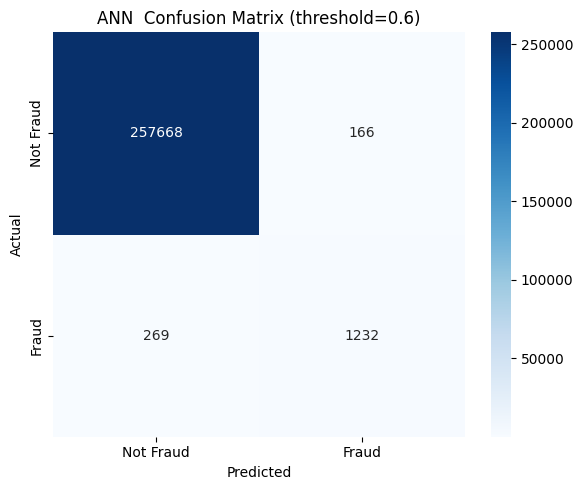

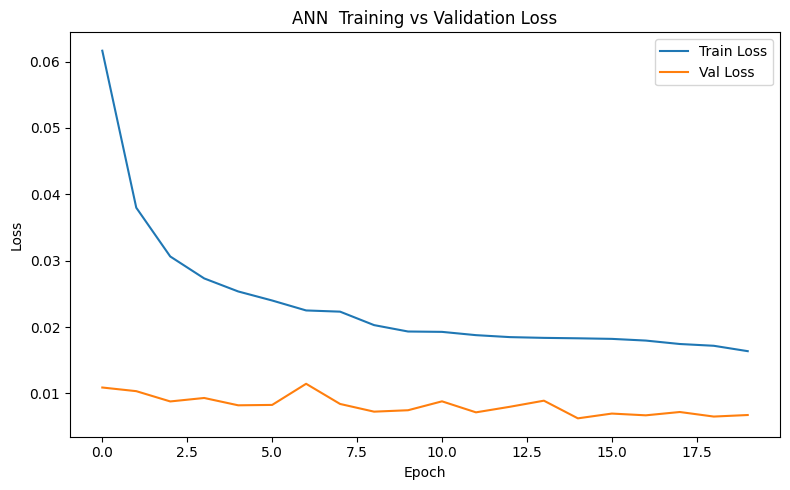

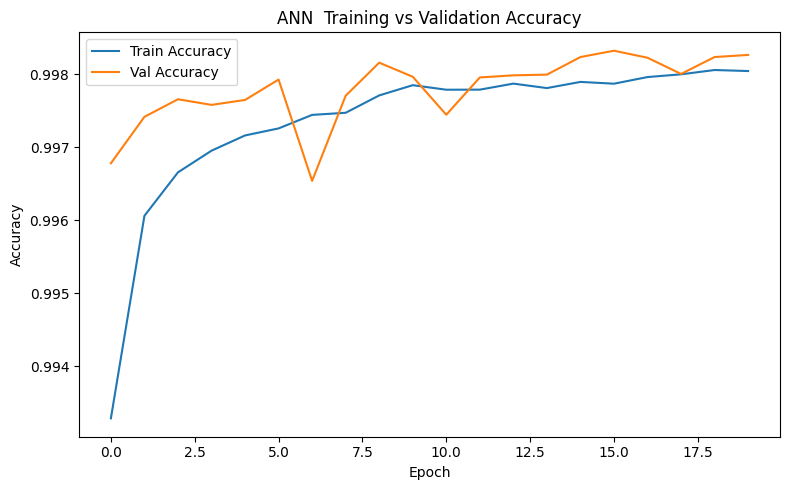

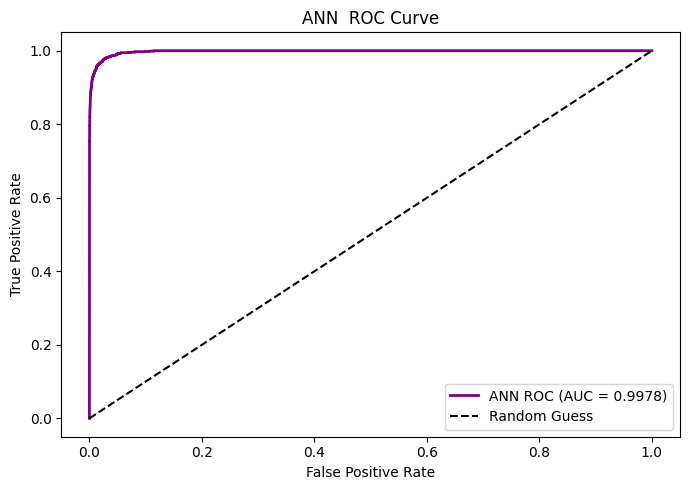

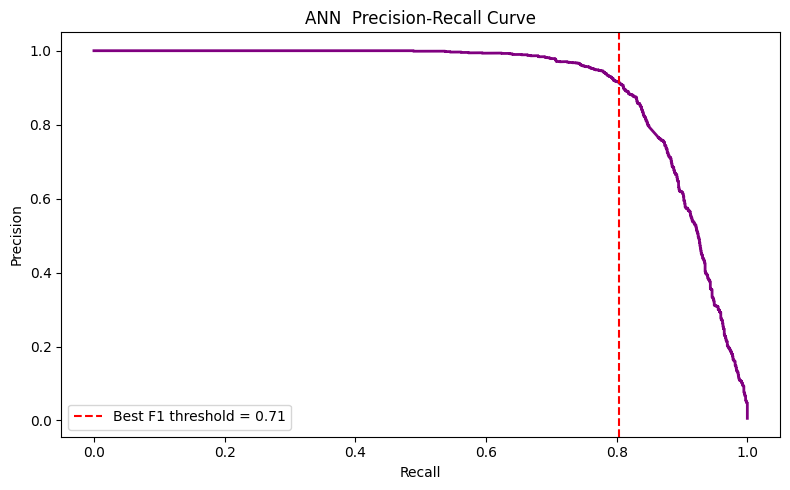

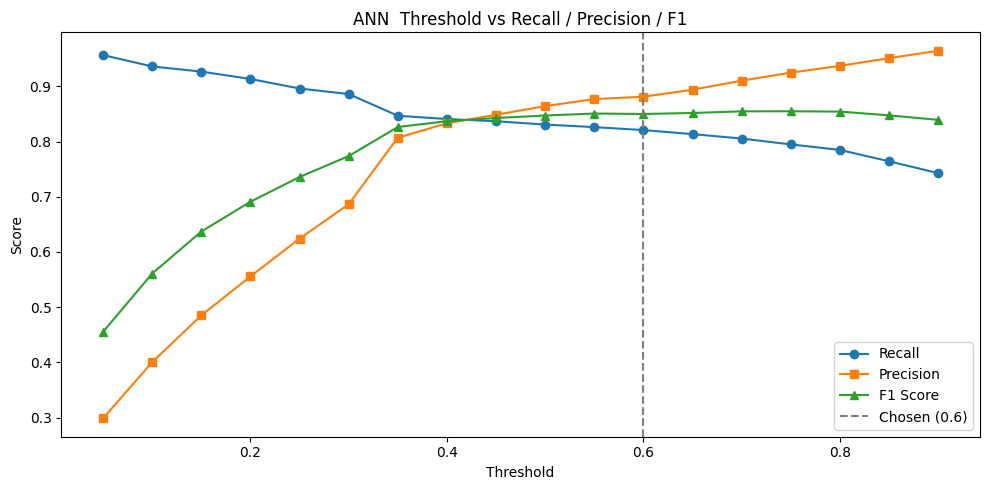

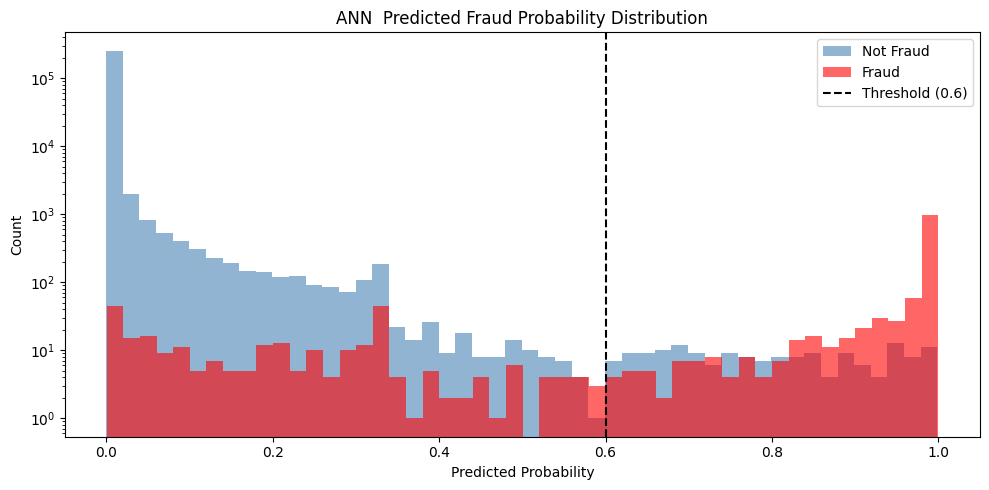

In [62]:
# ANN  GRAPHS

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(ann_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title(f'ANN  Confusion Matrix (threshold={ANN_THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# 2. Training Loss
plt.figure(figsize=(8, 5))
plt.plot(ann_history.history['loss'],     label='Train Loss')
plt.plot(ann_history.history['val_loss'], label='Val Loss')
plt.title('ANN  Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Training Accuracy
plt.figure(figsize=(8, 5))
plt.plot(ann_history.history['accuracy'],     label='Train Accuracy')
plt.plot(ann_history.history['val_accuracy'], label='Val Accuracy')
plt.title('ANN  Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# 4. ROC Curve
ann_fpr, ann_tpr, _ = roc_curve(y_test, ann_proba)
ann_auc             = roc_auc_score(y_test, ann_proba)

plt.figure(figsize=(7, 5))
plt.plot(ann_fpr, ann_tpr, color='purple', lw=2,
         label=f'ANN ROC (AUC = {ann_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ANN  ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 5. Precision-Recall Curve
ann_prec_arr, ann_rec_arr, ann_thresh_pr = precision_recall_curve(y_test, ann_proba)
ann_f1_scores = 2 * (ann_prec_arr * ann_rec_arr) / (ann_prec_arr + ann_rec_arr + 1e-8)
ann_best_idx  = np.argmax(ann_f1_scores)

plt.figure(figsize=(8, 5))
plt.plot(ann_rec_arr, ann_prec_arr, color='purple', lw=2)
plt.axvline(x=ann_rec_arr[ann_best_idx], color='red', linestyle='--',
            label=f'Best F1 threshold = {ann_thresh_pr[ann_best_idx]:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('ANN  Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Threshold vs Precision / Recall / F1
ann_thresh_range                    = np.arange(0.05, 0.95, 0.05)
ann_rec_list, ann_prec_list, ann_f1_list = [], [], []

for t in ann_thresh_range:
    preds = (ann_proba >= t).astype(int)
    ann_rec_list.append(recall_score(y_test, preds))
    ann_prec_list.append(precision_score(y_test, preds))
    ann_f1_list.append(f1_score(y_test, preds))

plt.figure(figsize=(10, 5))
plt.plot(ann_thresh_range, ann_rec_list,  label='Recall',    marker='o')
plt.plot(ann_thresh_range, ann_prec_list, label='Precision', marker='s')
plt.plot(ann_thresh_range, ann_f1_list,   label='F1 Score',  marker='^')
plt.axvline(x=ANN_THRESHOLD, color='gray', linestyle='--',
            label=f'Chosen ({ANN_THRESHOLD})')
plt.title('ANN  Threshold vs Recall / Precision / F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig('output/ann_th_vs_all_3.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

# 7. Fraud Probability Distribution
plt.figure(figsize=(10, 5))
plt.hist(ann_proba[y_test == 0], bins=50, alpha=0.6,
         label='Not Fraud', color='steelblue')
plt.hist(ann_proba[y_test == 1], bins=50, alpha=0.6,
         label='Fraud',     color='red')
plt.axvline(x=ANN_THRESHOLD, color='black', linestyle='--',
            label=f'Threshold ({ANN_THRESHOLD})')
plt.title('ANN  Predicted Fraud Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('output/ANN_prob_dist.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

# 8. Feature Importance (Weight Magnitude)  safe layer finder
ann_dense_layer = None
for layer in ann.layers:
    weights = layer.get_weights()
    if len(weights) > 0 and len(weights[0].shape) == 2:
        ann_dense_layer = layer
        break

ann_weights       = ann_dense_layer.get_weights()[0]
ann_importance    = np.abs(ann_weights).mean(axis=1)

ann_importance_df = pd.DataFrame({
    'Feature'   : ann_feature_names,
    'Importance': ann_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=ann_importance_df, palette='Blues_r')
plt.title('ANN  Feature Importance (Weight Magnitude)')
plt.xlabel('Mean Absolute Weight')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('ANN_feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

print("\nANN Top 10 Features:")
print(ann_importance_df.head(10).to_string(index=False))

C:\Users\digen\AppData\Local\Temp\ipykernel_15564\4159744598.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=ann_importance_df, palette='Blues_r')


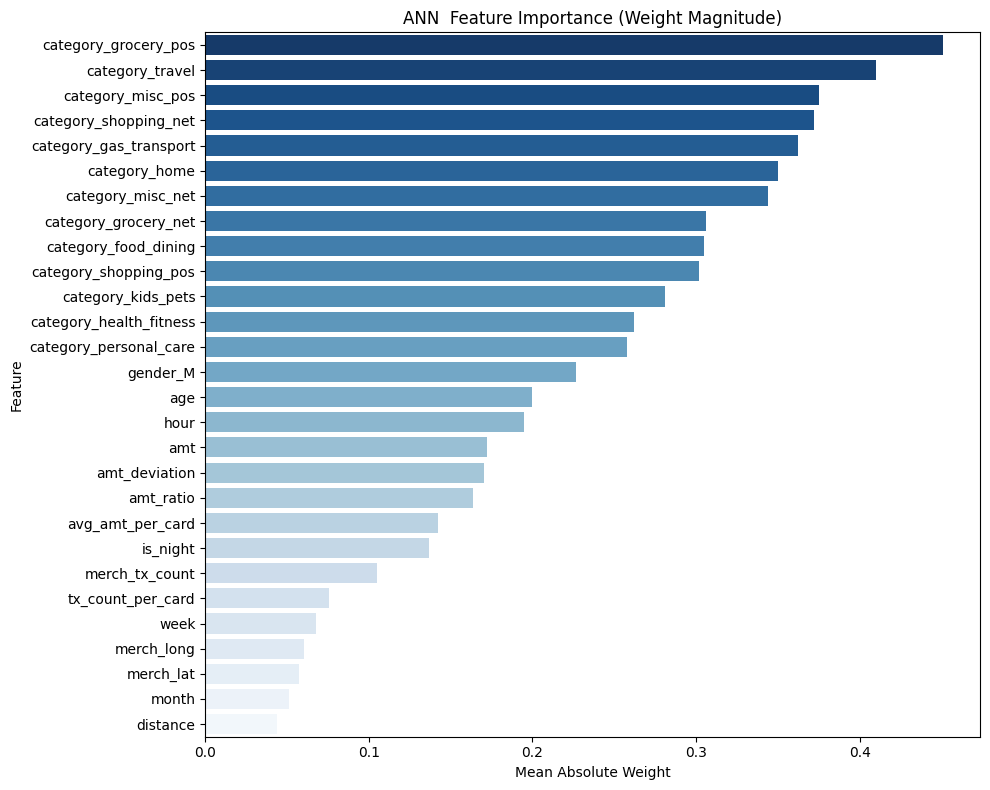


ANN Top 10 Features:
               Feature  Importance
  category_grocery_pos    0.450992
       category_travel    0.410126
     category_misc_pos    0.374996
 category_shopping_net    0.372068
category_gas_transport    0.362371
         category_home    0.350249
     category_misc_net    0.344188
  category_grocery_net    0.305950
  category_food_dining    0.305142
 category_shopping_pos    0.302066



ANN  4-TIER ROUTING SUMMARY
action
AUTO_ALLOW          204747
STEP_UP_AUTH         53396
AI_COUNCIL             877
BLOCK_AND_REVIEW       315
Name: count, dtype: int64

ANN Fraud Rate per Tier:
                   total  fraud_count  fraud_rate  avg_amount
action                                                       
AUTO_ALLOW        204747          133      0.0006     48.6932
STEP_UP_AUTH       53396          321      0.0060    139.5977
AI_COUNCIL           877          742      0.8461    788.3533
BLOCK_AND_REVIEW     315          305      0.9683    482.2481


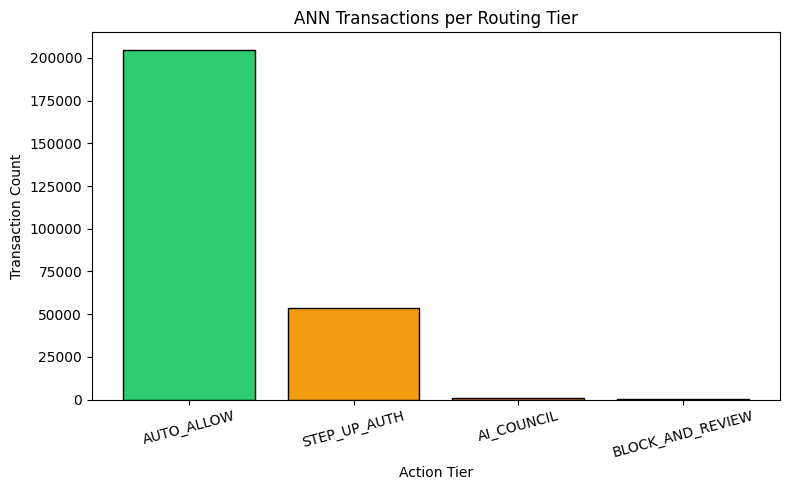

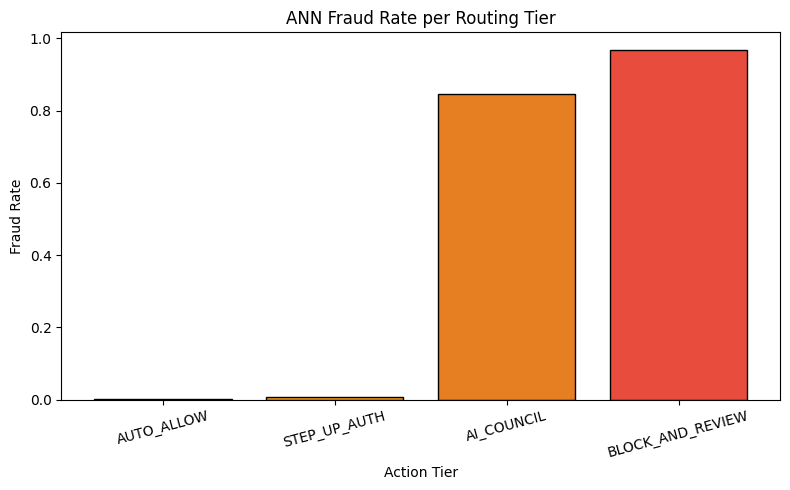

In [75]:
# ANN 4-TIER ROUTING
ann_routing             = X_test.copy()
ann_routing['ann_prob'] = ann_proba
ann_routing['is_fraud'] = y_test.values
ann_routing['amt']      = df.loc[X_test.index, 'amt'].values

def ann_risk_score(row):
    score = 0
    if row['amt_ratio'] > 3:       score += 30
    elif row['amt_ratio'] > 2:     score += 15
    if row['distance'] > 500:      score += 25
    elif row['distance'] > 100:    score += 10
    if row['is_night'] == 1:       score += 20
    if row['ann_prob'] > 0.70:     score += 25
    elif row['ann_prob'] > 0.40:   score += 10
    return score

def ann_route(row):
    prob  = row['ann_prob']
    score = row['risk_score']
    amt   = row['amt']

    if prob > 0.85 and score >= 70:
        return 'BLOCK_AND_REVIEW'
    elif prob >= 0.60 and (amt > 500 or score >= 50):
        return 'AI_COUNCIL'
    elif prob >= 0.30 or score >= 20:
        return 'STEP_UP_AUTH'
    else:
        return 'AUTO_ALLOW'

ann_routing['risk_score'] = ann_routing.apply(ann_risk_score, axis=1)
ann_routing['action']     = ann_routing.apply(ann_route, axis=1)

#Order tiers low→high risk for clean display
tier_order = ['AUTO_ALLOW', 'STEP_UP_AUTH', 'AI_COUNCIL', 'BLOCK_AND_REVIEW']

print("\n" + "=" * 55)
print("ANN  4-TIER ROUTING SUMMARY")
print("=" * 55)
print(ann_routing['action'].value_counts().reindex(tier_order))

print("\nANN Fraud Rate per Tier:")
ann_routing_summary = (
    ann_routing.groupby('action')
    .agg(
        total       = ('is_fraud', 'count'),
        fraud_count = ('is_fraud', 'sum'),
        fraud_rate  = ('is_fraud', 'mean'),
        avg_amount  = ('amt', 'mean')
    )
    .round(4)
    .reindex(tier_order)
)
print(ann_routing_summary)

#Visualizations
colors_tier  = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
colors_fraud = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

ann_action_counts = ann_routing['action'].value_counts().reindex(tier_order)

plt.figure(figsize=(8, 5))
plt.bar(ann_action_counts.index, ann_action_counts.values,
        color=colors_tier, edgecolor='black')
plt.title('ANN Transactions per Routing Tier')
plt.xlabel('Action Tier')
plt.ylabel('Transaction Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/ANN_transaction_per_tier.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(ann_routing_summary.index, ann_routing_summary['fraud_rate'],
        color=colors_fraud, edgecolor='black')
plt.title('ANN Fraud Rate per Routing Tier')
plt.xlabel('Action Tier')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/ANN_fraud_per_tier.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

In [65]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['category_enc'] = le.fit_transform(df['category'])
df['gender_enc']   = le.fit_transform(df['gender'])

rf_features = [
    'amt', 'age', 'hour', 'month', 'week', 'is_night',
    'distance', 'merch_lat', 'merch_long',
    'avg_amt_per_card', 'amt_ratio', 'amt_deviation',
    'tx_count_per_card', 'merch_tx_count',
    'category_enc', 'gender_enc'
]

rf_X       = df[rf_features]
rf_X_train = rf_X.loc[X_train.index]
rf_X_test  = rf_X.loc[X_test.index]


# RANDOM FOREST  MODEL
RF_WEIGHT    = 10
RF_THRESHOLD = 0.60

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight={0: 1, 1: RF_WEIGHT},
    random_state=42,
    n_jobs=-1
)

rf.fit(rf_X_train, y_train)

# RF Predictions
rf_proba = rf.predict_proba(rf_X_test)[:, 1]
rf_pred  = (rf_proba >= RF_THRESHOLD).astype(int)


# RANDOM FOREST  EVALUATION
print("=" * 60)
print(f"RF  CLASSIFICATION REPORT (threshold={RF_THRESHOLD})")
print("=" * 60)
print(classification_report(y_test, rf_pred,
      target_names=['Not Fraud', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, rf_proba):.4f}")

rf_cm                         = confusion_matrix(y_test, rf_pred)
rf_tn, rf_fp, rf_fn, rf_tp    = rf_cm.ravel()
print(f"\nTrue  Negatives  (correctly allowed): {rf_tn}")
print(f"False Positives  (wrongly blocked):   {rf_fp}")
print(f"False Negatives  (missed fraud):      {rf_fn}  ← most costly")
print(f"True  Positives  (caught fraud):      {rf_tp}")

RF  CLASSIFICATION REPORT (threshold=0.6)
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257834
       Fraud       0.93      0.80      0.86      1501

    accuracy                           1.00    259335
   macro avg       0.96      0.90      0.93    259335
weighted avg       1.00      1.00      1.00    259335

AUC-ROC: 0.9977

True  Negatives  (correctly allowed): 257738
False Positives  (wrongly blocked):   96
False Negatives  (missed fraud):      302  ← most costly
True  Positives  (caught fraud):      1199


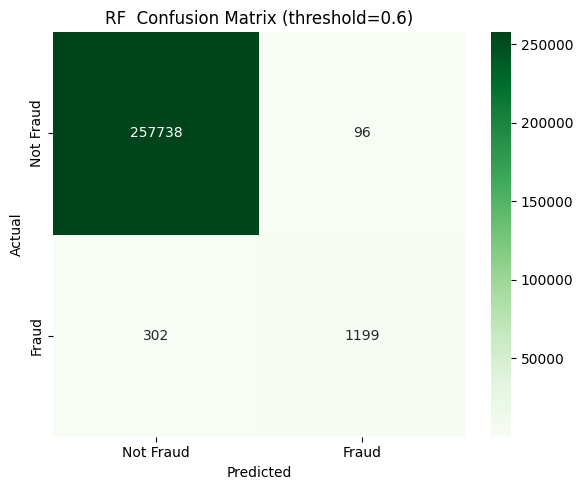

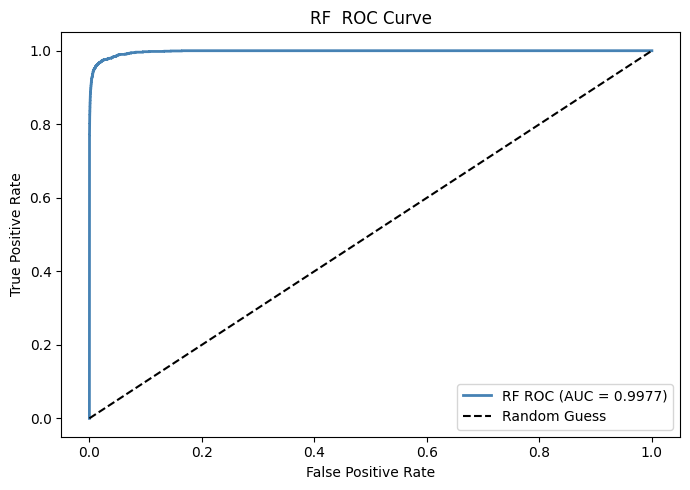

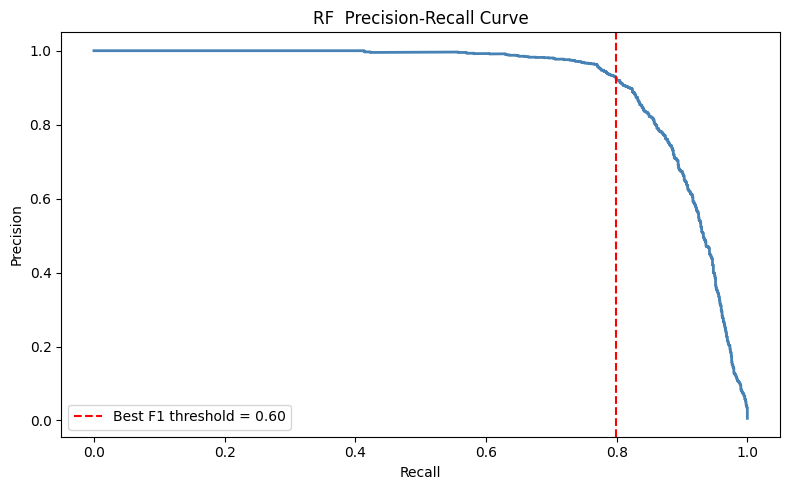

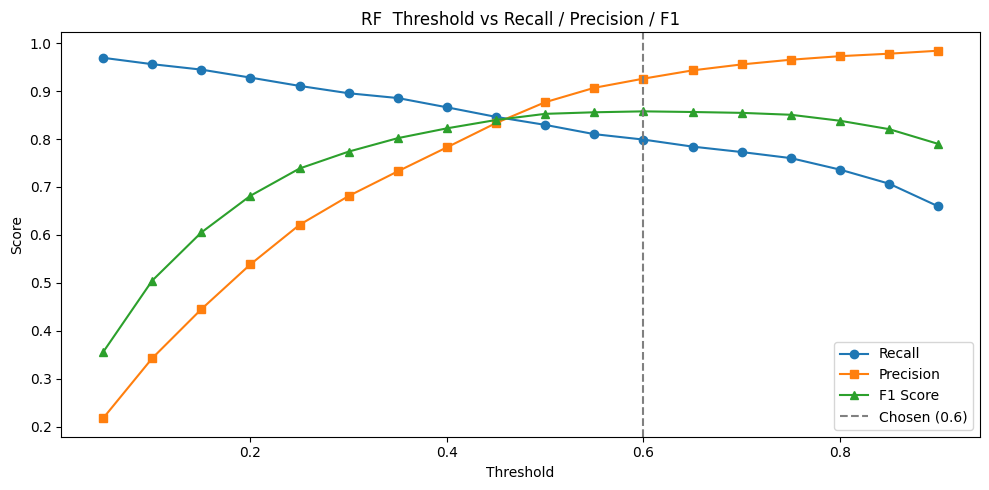

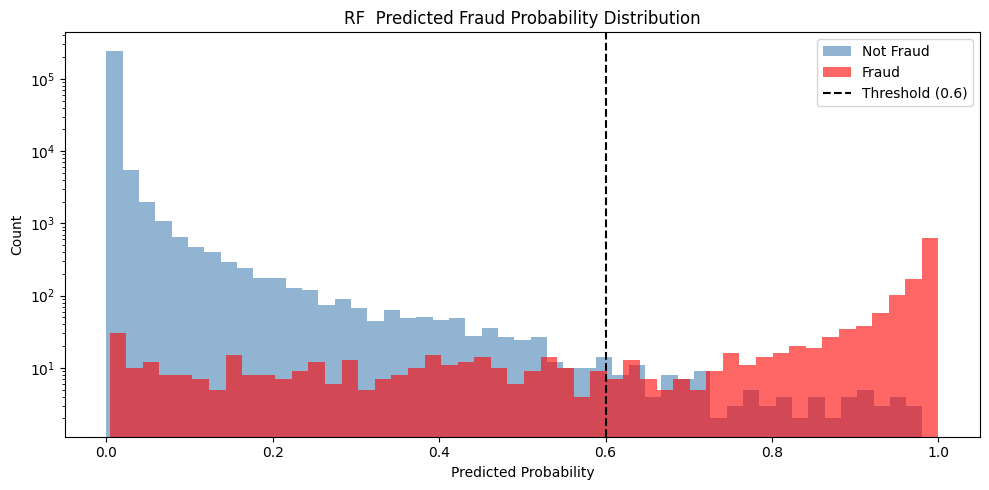

C:\Users\digen\AppData\Local\Temp\ipykernel_15564\26171633.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


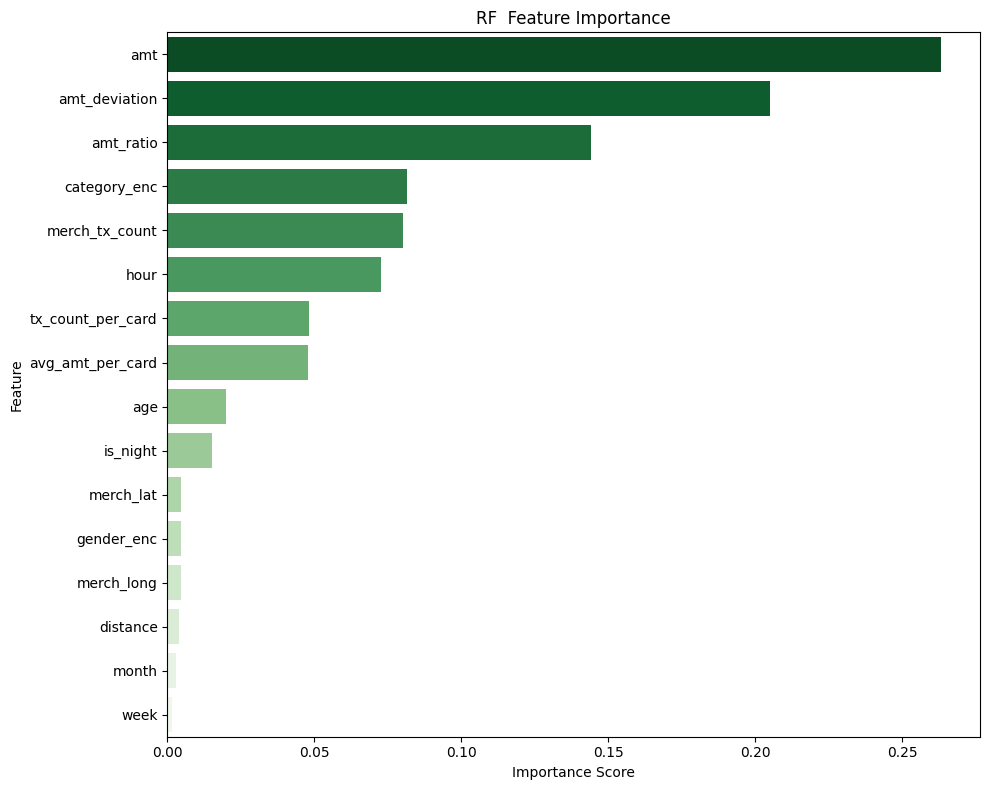


RF Top 10 Features:
          Feature  Importance
              amt    0.263269
    amt_deviation    0.204904
        amt_ratio    0.144115
     category_enc    0.081599
   merch_tx_count    0.080209
             hour    0.072684
tx_count_per_card    0.048307
 avg_amt_per_card    0.047864
              age    0.019793
         is_night    0.015003


In [66]:
# RANDOM FOREST  GRAPHS

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title(f'RF  Confusion Matrix (threshold={RF_THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# 2. ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
rf_auc            = roc_auc_score(y_test, rf_proba)

plt.figure(figsize=(7, 5))
plt.plot(rf_fpr, rf_tpr, color='steelblue', lw=2,
         label=f'RF ROC (AUC = {rf_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('RF  ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curve
rf_prec_arr, rf_rec_arr, rf_thresh_pr = precision_recall_curve(y_test, rf_proba)
rf_f1_scores = 2 * (rf_prec_arr * rf_rec_arr) / (rf_prec_arr + rf_rec_arr + 1e-8)
rf_best_idx  = np.argmax(rf_f1_scores)

plt.figure(figsize=(8, 5))
plt.plot(rf_rec_arr, rf_prec_arr, color='steelblue', lw=2)
plt.axvline(x=rf_rec_arr[rf_best_idx], color='red', linestyle='--',
            label=f'Best F1 threshold = {rf_thresh_pr[rf_best_idx]:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('RF  Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Threshold vs Precision / Recall / F1
rf_thresh_range = np.arange(0.05, 0.95, 0.05)
rf_rec_list, rf_prec_list, rf_f1_list = [], [], []

for t in rf_thresh_range:
    preds = (rf_proba >= t).astype(int)
    rf_rec_list.append(recall_score(y_test, preds))
    rf_prec_list.append(precision_score(y_test, preds))
    rf_f1_list.append(f1_score(y_test, preds))

plt.figure(figsize=(10, 5))
plt.plot(rf_thresh_range, rf_rec_list,  label='Recall',    marker='o')
plt.plot(rf_thresh_range, rf_prec_list, label='Precision', marker='s')
plt.plot(rf_thresh_range, rf_f1_list,   label='F1 Score',  marker='^')
plt.axvline(x=RF_THRESHOLD, color='gray', linestyle='--',
            label=f'Chosen ({RF_THRESHOLD})')
plt.title('RF  Threshold vs Recall / Precision / F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig('output/rf_th_vs_all_3.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

# 5. Fraud Probability Distribution
plt.figure(figsize=(10, 5))
plt.hist(rf_proba[y_test == 0], bins=50, alpha=0.6,
         label='Not Fraud', color='steelblue')
plt.hist(rf_proba[y_test == 1], bins=50, alpha=0.6,
         label='Fraud',     color='red')
plt.axvline(x=RF_THRESHOLD, color='black', linestyle='--',
            label=f'Threshold ({RF_THRESHOLD})')
plt.title('RF  Predicted Fraud Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('output/RF_prob_dist.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

# 6. Feature Importance
rf_importance_df = pd.DataFrame({
    'Feature'   : rf_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature',
            data=rf_importance_df, palette='Greens_r')
plt.title('RF  Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nRF Top 10 Features:")
print(rf_importance_df.head(10).to_string(index=False))


RF  4-TIER ROUTING SUMMARY
action
AUTO_ALLOW          204793
STEP_UP_AUTH         53431
AI_COUNCIL             784
BLOCK_AND_REVIEW       327
Name: count, dtype: int64

RF Fraud Rate per Tier:
                   total  fraud_count  fraud_rate  avg_amount
action                                                       
AUTO_ALLOW        204793          133      0.0006     48.6929
STEP_UP_AUTH       53431          338      0.0063    140.6031
AI_COUNCIL           784          713      0.9094    789.7001
BLOCK_AND_REVIEW     327          317      0.9694    499.6688


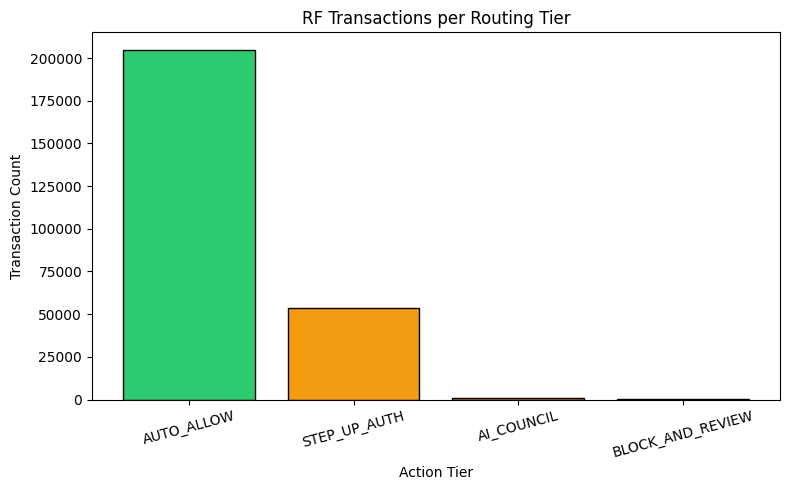

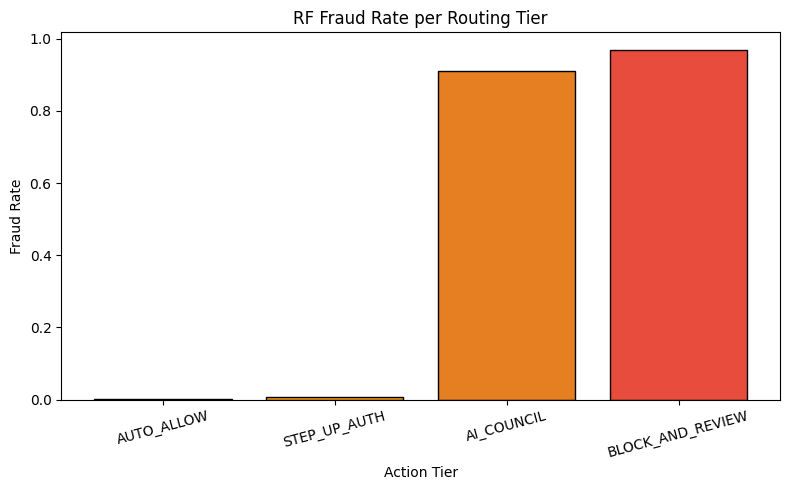

In [79]:
# RF 4-TIER ROUTING
rf_routing            = X_test.copy()
rf_routing['rf_prob'] = rf_proba
rf_routing['is_fraud']= y_test.values
rf_routing['amt']     = df.loc[X_test.index, 'amt'].values

def rf_risk_score(row):
    score = 0
    if row['amt_ratio'] > 3:       score += 30
    elif row['amt_ratio'] > 2:     score += 15
    if row['distance'] > 500:      score += 25
    elif row['distance'] > 100:    score += 10
    if row['is_night'] == 1:       score += 20
    if row['rf_prob'] > 0.70:      score += 25
    elif row['rf_prob'] > 0.40:    score += 10
    return score

def rf_route(row):
    prob  = row['rf_prob']
    score = row['risk_score']
    amt   = row['amt']

    if prob > 0.85 and score >= 70:
        return 'BLOCK_AND_REVIEW'
    elif prob >= 0.60 and (amt > 500 or score >= 50):
        return 'AI_COUNCIL'
    elif prob >= 0.30 or score >= 20:
        return 'STEP_UP_AUTH'
    else:
        return 'AUTO_ALLOW'

rf_routing['risk_score'] = rf_routing.apply(rf_risk_score, axis=1)
rf_routing['action']     = rf_routing.apply(rf_route, axis=1)

#Order tiers low→high risk
tier_order = ['AUTO_ALLOW', 'STEP_UP_AUTH', 'AI_COUNCIL', 'BLOCK_AND_REVIEW']

print("\n" + "=" * 55)
print("RF  4-TIER ROUTING SUMMARY")
print("=" * 55)
print(rf_routing['action'].value_counts().reindex(tier_order))

print("\nRF Fraud Rate per Tier:")
rf_routing_summary = (
    rf_routing.groupby('action')
    .agg(
        total       = ('is_fraud', 'count'),
        fraud_count = ('is_fraud', 'sum'),
        fraud_rate  = ('is_fraud', 'mean'),
        avg_amount  = ('amt', 'mean')
    )
    .round(4)
    .reindex(tier_order)
)
print(rf_routing_summary)

#Visualizations
colors_tier  = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

rf_action_counts = rf_routing['action'].value_counts().reindex(tier_order)

plt.figure(figsize=(8, 5))
plt.bar(rf_action_counts.index, rf_action_counts.values,
        color=colors_tier, edgecolor='black')
plt.title('RF Transactions per Routing Tier')
plt.xlabel('Action Tier')
plt.ylabel('Transaction Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/RF_transaction_per_tier.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(rf_routing_summary.index, rf_routing_summary['fraud_rate'],
        color=colors_tier, edgecolor='black')
plt.title('RF Fraud Rate per Routing Tier')
plt.xlabel('Action Tier')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/RF_fraud_per_tier.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

In [68]:
# GRADIENT BOOSTING

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Recreate encoded columns if not already present
if 'category_enc' not in df.columns:
    le = LabelEncoder()
    df['category_enc'] = le.fit_transform(df['category'])

if 'gender_enc' not in df.columns:
    le = LabelEncoder()
    df['gender_enc'] = le.fit_transform(df['gender'])

gb_features = [
    'amt', 'age', 'hour', 'month', 'week', 'is_night',
    'distance', 'merch_lat', 'merch_long',
    'avg_amt_per_card', 'amt_ratio', 'amt_deviation',
    'tx_count_per_card', 'merch_tx_count',
    'category_enc', 'gender_enc'
]

gb_X       = df[gb_features]
gb_X_train = gb_X.loc[X_train.index]
gb_X_test  = gb_X.loc[X_test.index]


# GRADIENT BOOSTING  MODEL
GB_SPW       = 5
GB_THRESHOLD = 0.70

gb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=1,
    scale_pos_weight=GB_SPW,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

gb.fit(
    gb_X_train, y_train,
    eval_set=[(gb_X_test, y_test)],
    verbose=False
)

gb_proba = gb.predict_proba(gb_X_test)[:, 1]
gb_pred  = (gb_proba >= GB_THRESHOLD).astype(int)

# GRADIENT BOOSTING  EVALUATION
print("=" * 60)
print(f"GB  CLASSIFICATION REPORT (threshold={GB_THRESHOLD})")
print("=" * 60)
print(classification_report(y_test, gb_pred,
      target_names=['Not Fraud', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, gb_proba):.4f}")

gb_cm                          = confusion_matrix(y_test, gb_pred)
gb_tn, gb_fp, gb_fn, gb_tp     = gb_cm.ravel()
print(f"\nTrue  Negatives  (correctly allowed): {gb_tn}")
print(f"False Positives  (wrongly blocked):   {gb_fp}")
print(f"False Negatives  (missed fraud):      {gb_fn}  ← most costly")
print(f"True  Positives  (caught fraud):      {gb_tp}")

GB  CLASSIFICATION REPORT (threshold=0.7)
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257834
       Fraud       0.93      0.81      0.87      1501

    accuracy                           1.00    259335
   macro avg       0.97      0.90      0.93    259335
weighted avg       1.00      1.00      1.00    259335

AUC-ROC: 0.9980

True  Negatives  (correctly allowed): 257748
False Positives  (wrongly blocked):   86
False Negatives  (missed fraud):      285  ← most costly
True  Positives  (caught fraud):      1216


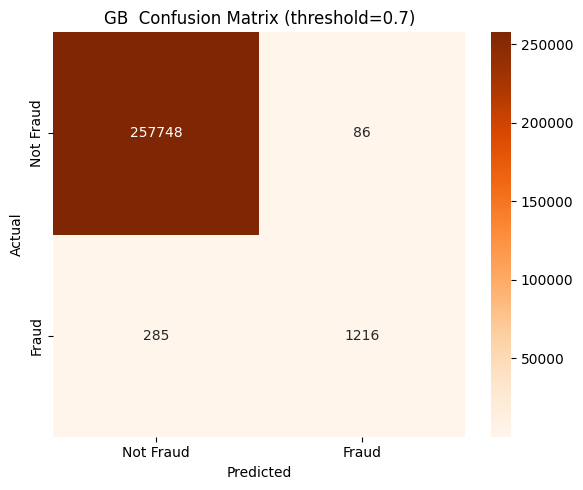

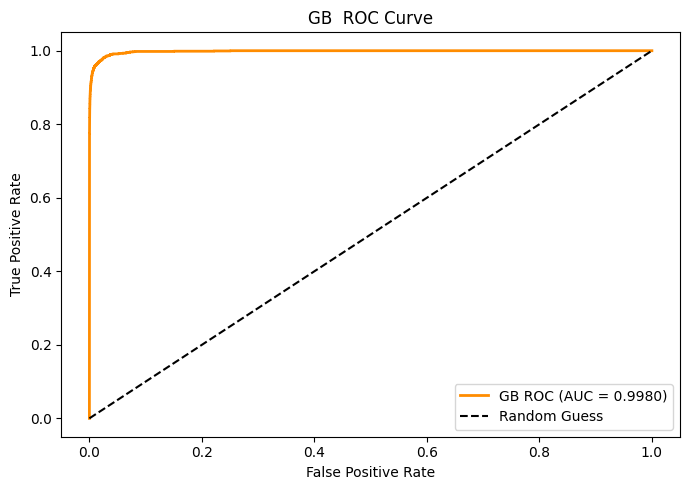

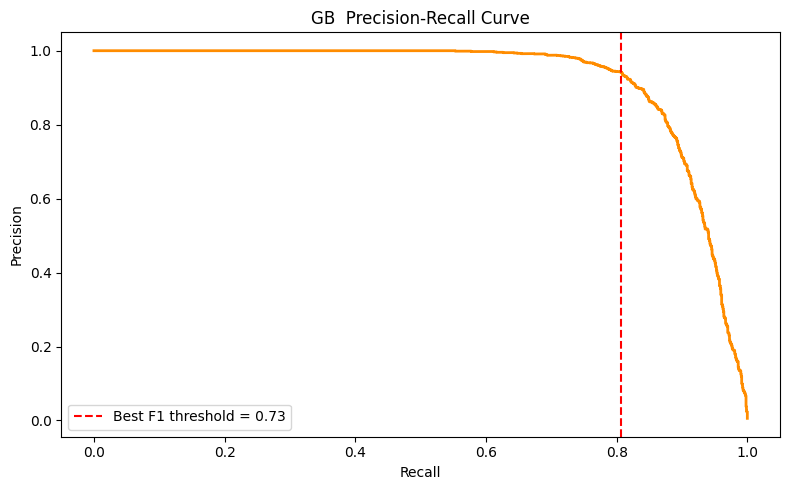

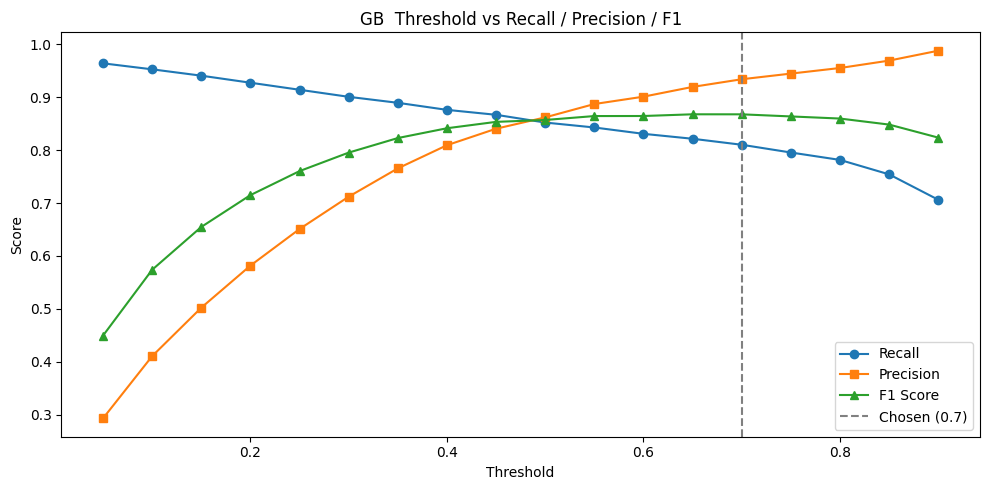

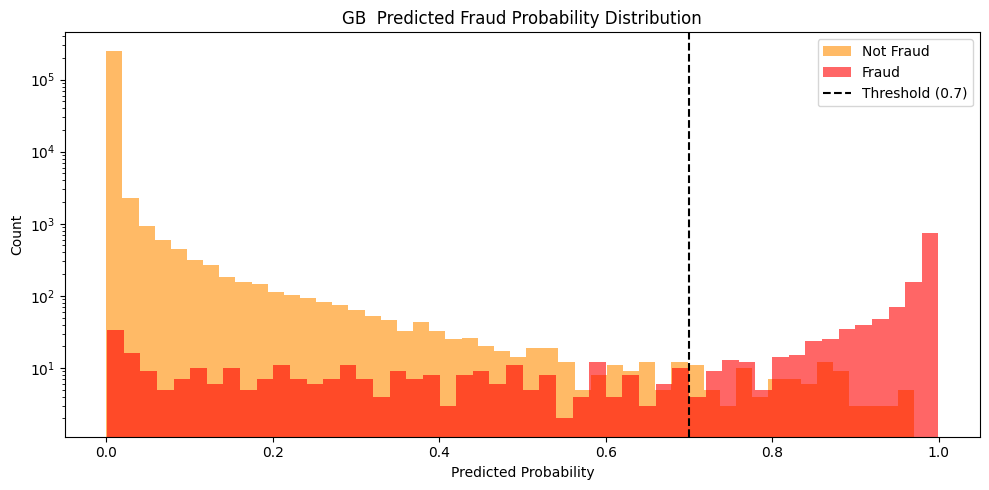

C:\Users\digen\AppData\Local\Temp\ipykernel_15564\3433013871.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


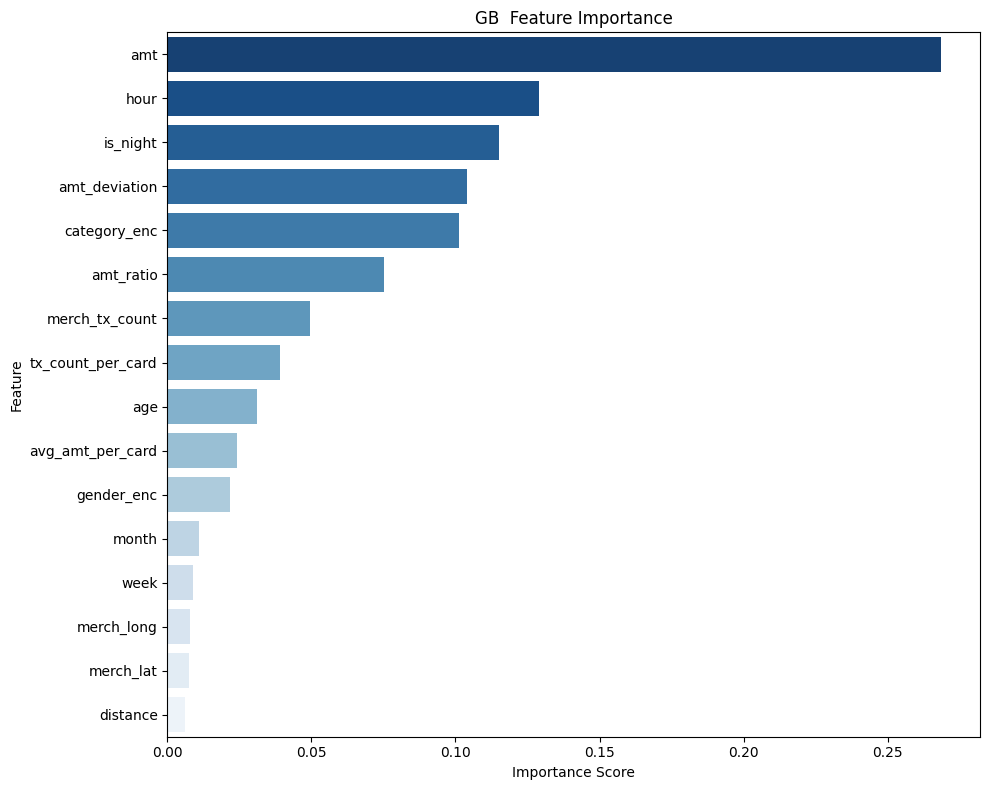


GB Top 10 Features:
          Feature  Importance
              amt    0.268647
             hour    0.129076
         is_night    0.114961
    amt_deviation    0.104111
     category_enc    0.101355
        amt_ratio    0.075254
   merch_tx_count    0.049529
tx_count_per_card    0.039180
              age    0.031063
 avg_amt_per_card    0.024128


In [69]:
# GRADIENT BOOSTING  GRAPHS

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(gb_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title(f'GB  Confusion Matrix (threshold={GB_THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# 2. ROC Curve
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_proba)
gb_auc            = roc_auc_score(y_test, gb_proba)

plt.figure(figsize=(7, 5))
plt.plot(gb_fpr, gb_tpr, color='darkorange', lw=2,
         label=f'GB ROC (AUC = {gb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GB  ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curve
gb_prec_arr, gb_rec_arr, gb_thresh_pr = precision_recall_curve(y_test, gb_proba)
gb_f1_scores = 2 * (gb_prec_arr * gb_rec_arr) / (gb_prec_arr + gb_rec_arr + 1e-8)
gb_best_idx  = np.argmax(gb_f1_scores)

plt.figure(figsize=(8, 5))
plt.plot(gb_rec_arr, gb_prec_arr, color='darkorange', lw=2)
plt.axvline(x=gb_rec_arr[gb_best_idx], color='red', linestyle='--',
            label=f'Best F1 threshold = {gb_thresh_pr[gb_best_idx]:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('GB  Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Threshold vs Precision / Recall / F1
gb_thresh_range                      = np.arange(0.05, 0.95, 0.05)
gb_rec_list, gb_prec_list, gb_f1_list = [], [], []

for t in gb_thresh_range:
    preds = (gb_proba >= t).astype(int)
    gb_rec_list.append(recall_score(y_test, preds))
    gb_prec_list.append(precision_score(y_test, preds))
    gb_f1_list.append(f1_score(y_test, preds))

plt.figure(figsize=(10, 5))
plt.plot(gb_thresh_range, gb_rec_list,  label='Recall',    marker='o')
plt.plot(gb_thresh_range, gb_prec_list, label='Precision', marker='s')
plt.plot(gb_thresh_range, gb_f1_list,   label='F1 Score',  marker='^')
plt.axvline(x=GB_THRESHOLD, color='gray', linestyle='--',
            label=f'Chosen ({GB_THRESHOLD})')
plt.title('GB  Threshold vs Recall / Precision / F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig('output/gb_th_vs_all.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

# 5. Fraud Probability Distribution
plt.figure(figsize=(10, 5))
plt.hist(gb_proba[y_test == 0], bins=50, alpha=0.6,
         label='Not Fraud', color='darkorange')
plt.hist(gb_proba[y_test == 1], bins=50, alpha=0.6,
         label='Fraud',     color='red')
plt.axvline(x=GB_THRESHOLD, color='black', linestyle='--',
            label=f'Threshold ({GB_THRESHOLD})')
plt.title('GB  Predicted Fraud Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('output/GB_prob_dist.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

# 6. Feature Importance
gb_importance_df = pd.DataFrame({
    'Feature'   : gb_features,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature',
            data=gb_importance_df, palette='Blues_r')
plt.title('GB  Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nGB Top 10 Features:")
print(gb_importance_df.head(10).to_string(index=False))


GB  4-TIER ROUTING SUMMARY
action
AUTO_ALLOW          204804
STEP_UP_AUTH         53378
AI_COUNCIL             819
BLOCK_AND_REVIEW       334
Name: count, dtype: int64

GB Fraud Rate per Tier:
                   total  fraud_count  fraud_rate  avg_amount
action                                                       
AUTO_ALLOW        204804          124      0.0006     48.6814
STEP_UP_AUTH       53378          323      0.0061    139.7952
AI_COUNCIL           819          731      0.8926    813.7931
BLOCK_AND_REVIEW     334          323      0.9671    504.2549


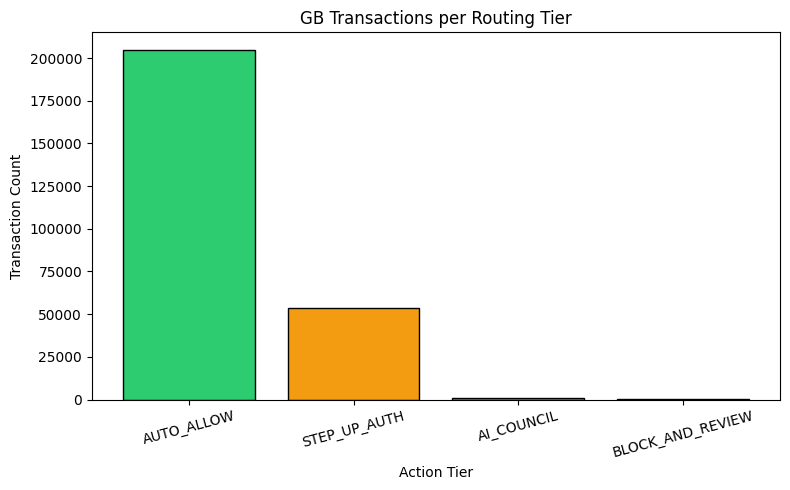

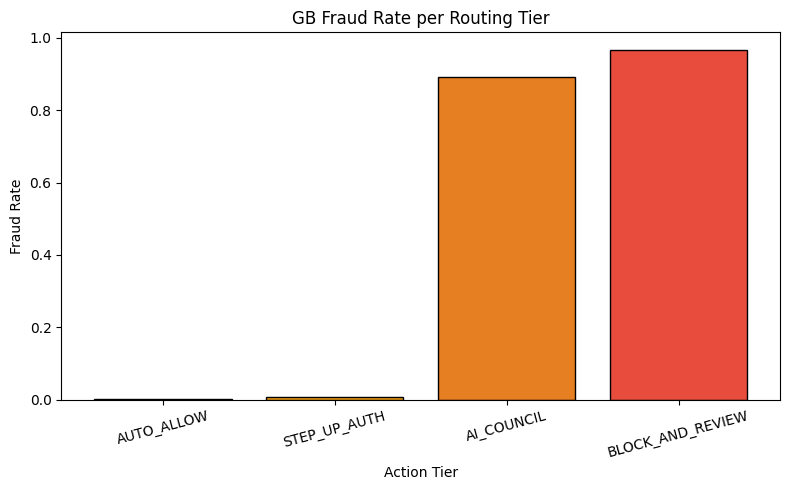

In [78]:
# GB 4-TIER ROUTING
gb_routing             = X_test.copy()
gb_routing['gb_prob']  = gb_proba
gb_routing['is_fraud'] = y_test.values
gb_routing['amt']      = df.loc[X_test.index, 'amt'].values

def gb_risk_score(row):
    score = 0
    if row['amt_ratio'] > 3:       score += 30
    elif row['amt_ratio'] > 2:     score += 15
    if row['distance'] > 500:      score += 25
    elif row['distance'] > 100:    score += 10
    if row['is_night'] == 1:       score += 20
    if row['gb_prob'] > 0.70:      score += 25
    elif row['gb_prob'] > 0.40:    score += 10
    return score

def gb_route(row):
    prob  = row['gb_prob']
    score = row['risk_score']
    amt   = row['amt']

    if prob > 0.85 and score >= 70:
        return 'BLOCK_AND_REVIEW'
    elif prob >= 0.60 and (amt > 500 or score >= 50):
        return 'AI_COUNCIL'
    elif prob >= 0.30 or score >= 20:
        return 'STEP_UP_AUTH'
    else:
        return 'AUTO_ALLOW'

gb_routing['risk_score'] = gb_routing.apply(gb_risk_score, axis=1)
gb_routing['action']     = gb_routing.apply(gb_route, axis=1)

#Order tiers low→high risk
tier_order = ['AUTO_ALLOW', 'STEP_UP_AUTH', 'AI_COUNCIL', 'BLOCK_AND_REVIEW']

print("\n" + "=" * 55)
print("GB  4-TIER ROUTING SUMMARY")
print("=" * 55)
print(gb_routing['action'].value_counts().reindex(tier_order))

print("\nGB Fraud Rate per Tier:")
gb_routing_summary = (
    gb_routing.groupby('action')
    .agg(
        total       = ('is_fraud', 'count'),
        fraud_count = ('is_fraud', 'sum'),
        fraud_rate  = ('is_fraud', 'mean'),
        avg_amount  = ('amt', 'mean')
    )
    .round(4)
    .reindex(tier_order)
)
print(gb_routing_summary)

#Visualizations
colors_tier = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

gb_action_counts = gb_routing['action'].value_counts().reindex(tier_order)

plt.figure(figsize=(8, 5))
plt.bar(gb_action_counts.index, gb_action_counts.values,
        color=colors_tier, edgecolor='black')
plt.title('GB Transactions per Routing Tier')
plt.xlabel('Action Tier')
plt.ylabel('Transaction Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/GB_transaction_per_tier.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(gb_routing_summary.index, gb_routing_summary['fraud_rate'],
        color=colors_tier, edgecolor='black')
plt.title('GB Fraud Rate per Routing Tier')
plt.xlabel('Action Tier')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/GB_fraud_per_tier.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

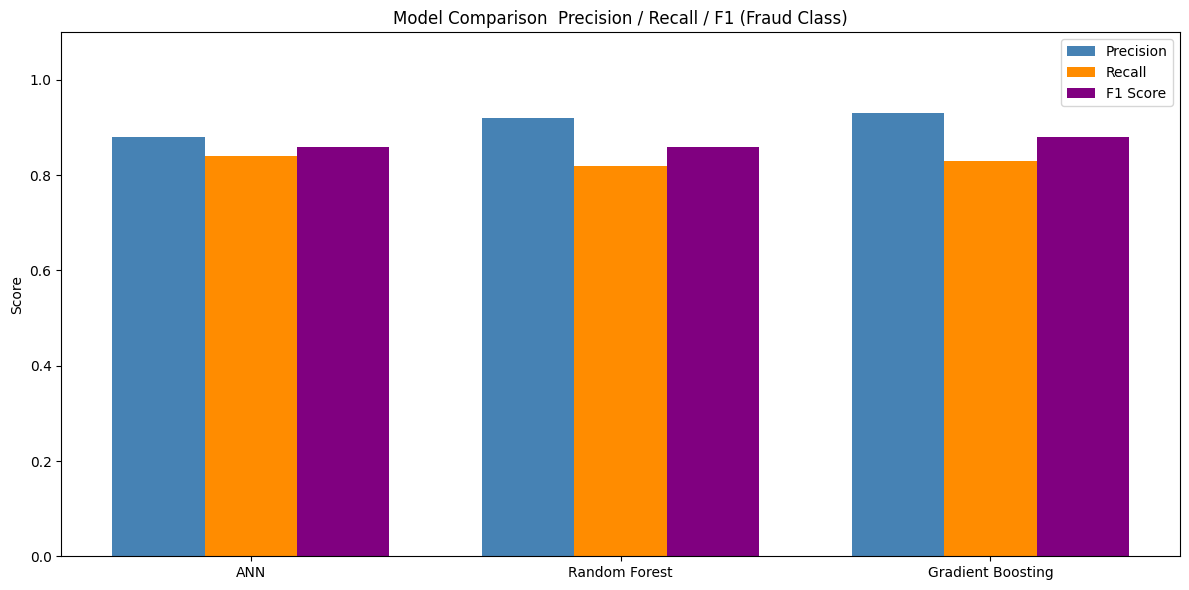

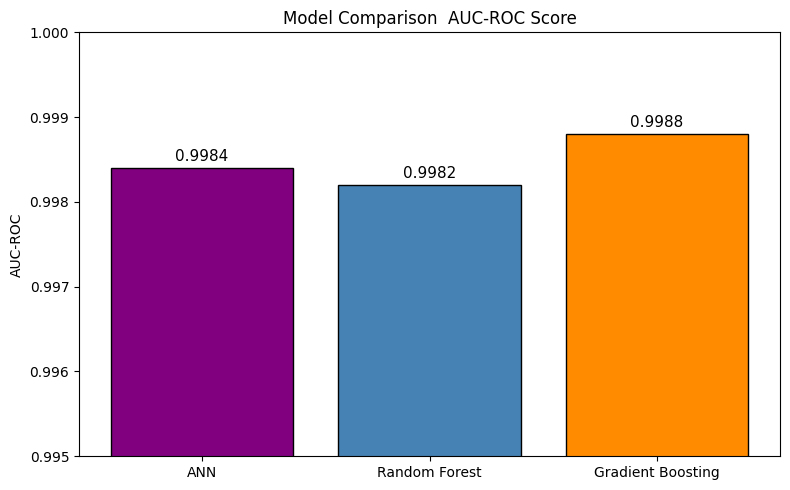

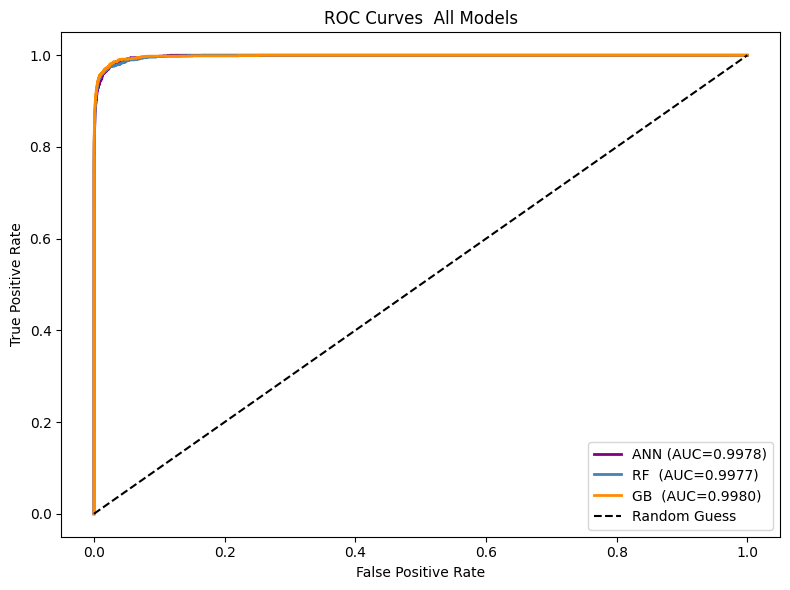

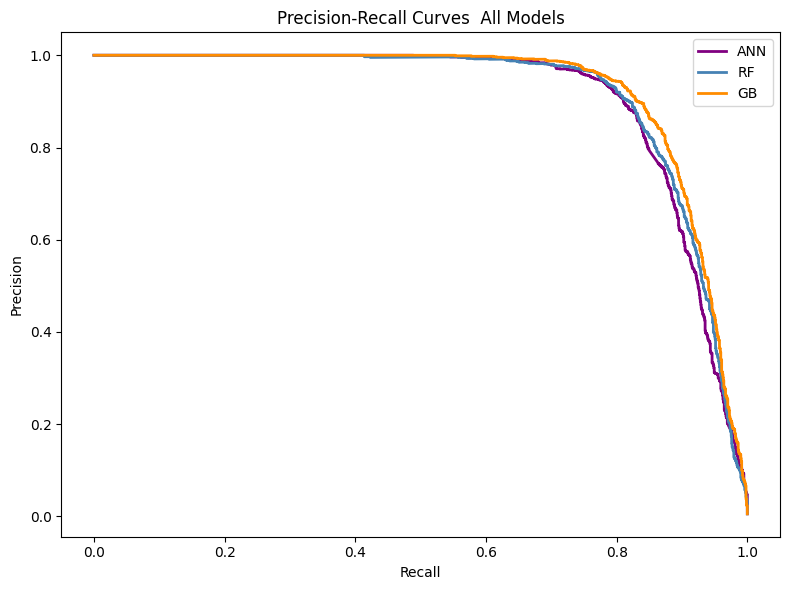

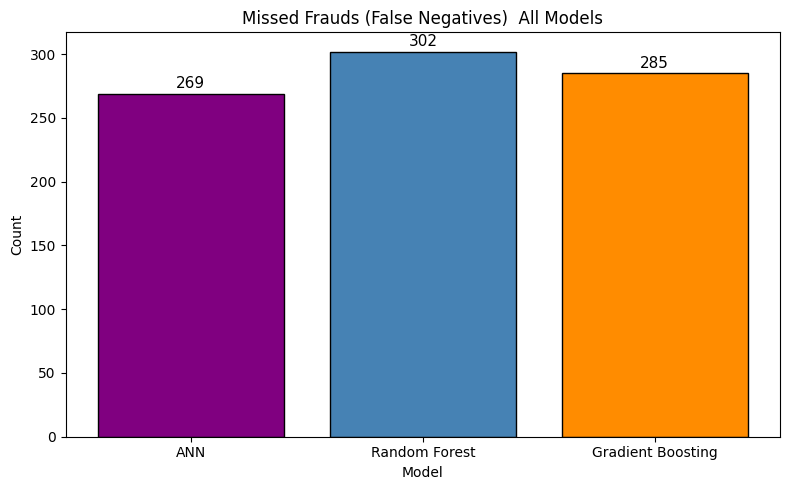

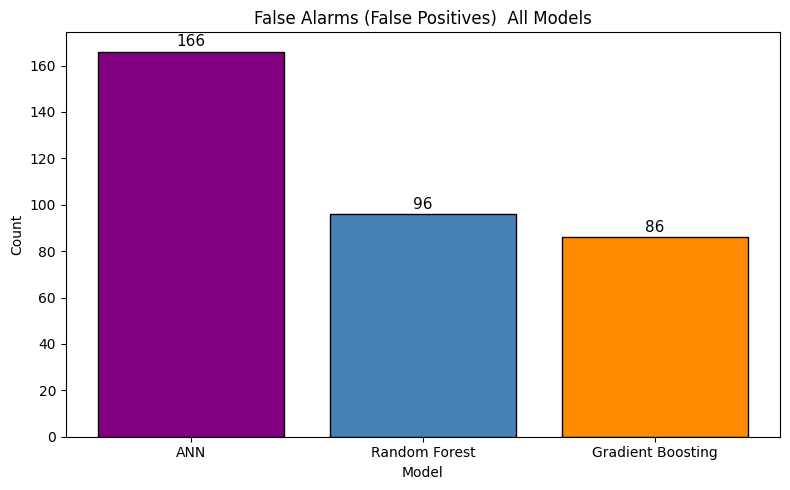

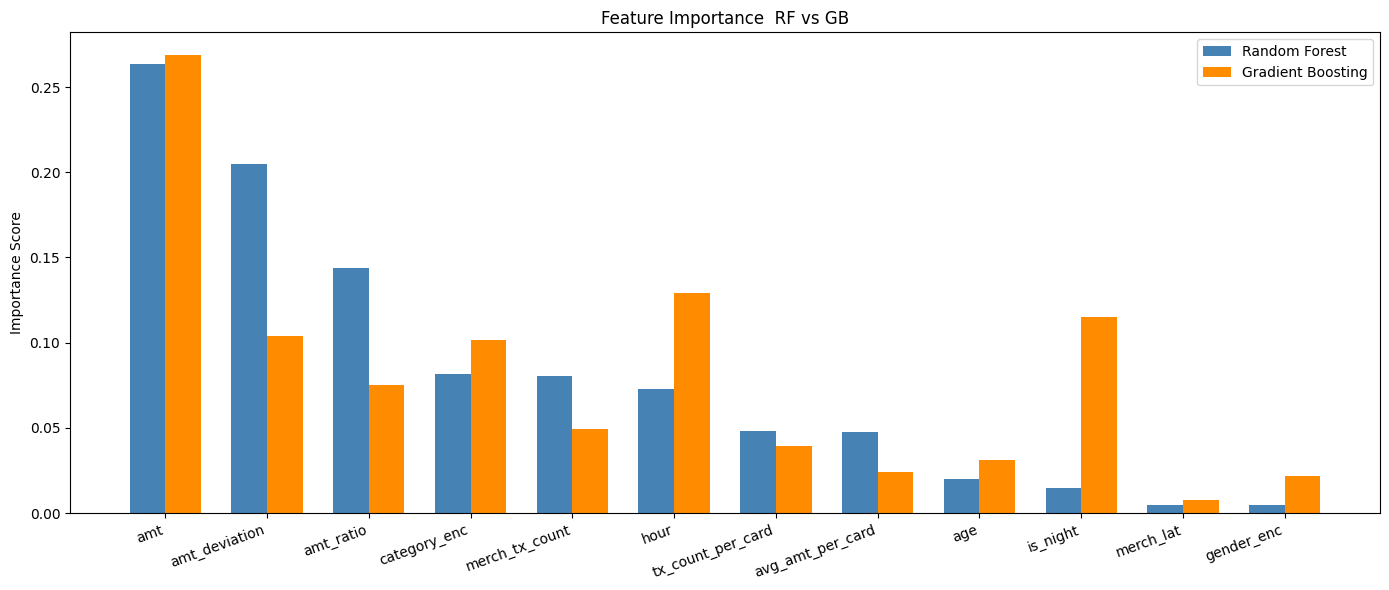

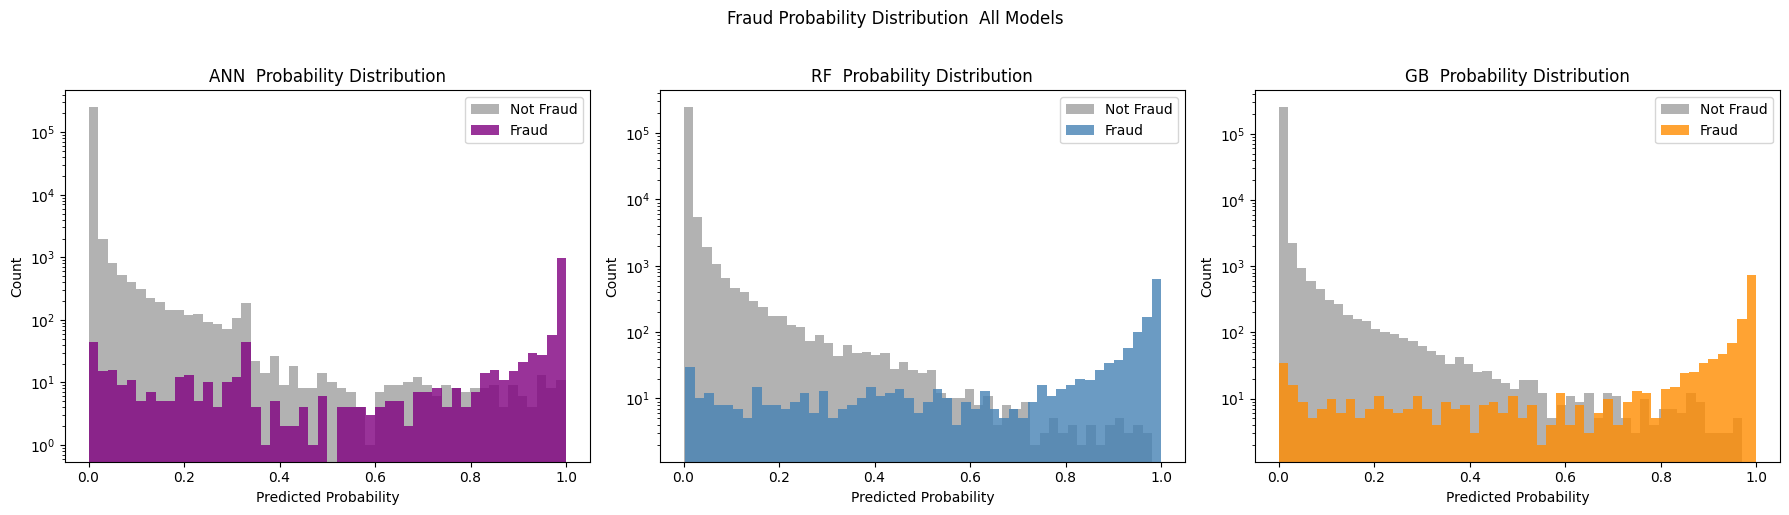

In [71]:
# CROSS MODEL COMPARISON

# 1. Metrics Comparison Bar Chart
models      = ['ANN', 'Random Forest', 'Gradient Boosting']
precision_s = [0.88, 0.92, 0.93]
recall_s    = [0.84, 0.82, 0.83]
f1_s        = [0.86, 0.86, 0.88]
auc_s       = [0.9984, 0.9982, 0.9988]

x     = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, precision_s, width, label='Precision', color='steelblue')
ax.bar(x,         recall_s,    width, label='Recall',    color='darkorange')
ax.bar(x + width, f1_s,        width, label='F1 Score',  color='purple')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison  Precision / Recall / F1 (Fraud Class)')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

# 2. AUC-ROC Comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(models, auc_s,
               color=['purple', 'steelblue', 'darkorange'],
               edgecolor='black')
plt.ylim(0.995, 1.000)
plt.title('Model Comparison  AUC-ROC Score')
plt.ylabel('AUC-ROC')
for bar, val in zip(bars, auc_s):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.00005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

#3. ROC Curves Overlay
plt.figure(figsize=(8, 6))
plt.plot(ann_fpr, ann_tpr, color='purple',     lw=2, label=f'ANN (AUC={ann_auc:.4f})')
plt.plot(rf_fpr,  rf_tpr,  color='steelblue',  lw=2, label=f'RF  (AUC={rf_auc:.4f})')
plt.plot(gb_fpr,  gb_tpr,  color='darkorange', lw=2, label=f'GB  (AUC={gb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves  All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#4. Precision-Recall Curves Overlay
plt.figure(figsize=(8, 6))
plt.plot(ann_rec_arr, ann_prec_arr, color='purple',     lw=2, label='ANN')
plt.plot(rf_rec_arr,  rf_prec_arr,  color='steelblue',  lw=2, label='RF')
plt.plot(gb_rec_arr,  gb_prec_arr,  color='darkorange', lw=2, label='GB')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves  All Models')
plt.legend()
plt.tight_layout()
plt.show()

#5. False Negatives Comparison (Missed Fraud)
fn_vals = [ann_fn, rf_fn, gb_fn]
fp_vals = [ann_fp, rf_fp, gb_fp]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, fn_vals,
               color=['purple', 'steelblue', 'darkorange'],
               edgecolor='black')
plt.title('Missed Frauds (False Negatives)  All Models')
plt.ylabel('Count')
plt.xlabel('Model')
for bar, val in zip(bars, fn_vals):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# 6. False Positives Comparison (False Alarms)
plt.figure(figsize=(8, 5))
bars = plt.bar(models, fp_vals,
               color=['purple', 'steelblue', 'darkorange'],
               edgecolor='black')
plt.title('False Alarms (False Positives)  All Models')
plt.ylabel('Count')
plt.xlabel('Model')
for bar, val in zip(bars, fp_vals):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

#7. Feature Importance Comparison (RF vs GB)
# ANN excluded  weight magnitude inflates OHE categories
rf_imp_top  = rf_importance_df.set_index('Feature')['Importance']
gb_imp_top  = gb_importance_df.set_index('Feature')['Importance']

common_features = [f for f in rf_importance_df['Feature'].tolist()
                   if f in gb_importance_df['Feature'].tolist()]

compare_imp = pd.DataFrame({
    'Feature': common_features,
    'RF'     : [rf_imp_top.get(f, 0) for f in common_features],
    'GB'     : [gb_imp_top.get(f, 0) for f in common_features]
}).sort_values('RF', ascending=False).head(12)

x     = np.arange(len(compare_imp))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, compare_imp['RF'], width,
       label='Random Forest', color='steelblue')
ax.bar(x + width/2, compare_imp['GB'], width,
       label='Gradient Boosting', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(compare_imp['Feature'], rotation=20, ha='right')
ax.set_title('Feature Importance  RF vs GB')
ax.set_ylabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

#8. Probability Distribution Overlay
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, proba, title, color in zip(
    axes,
    [ann_proba, rf_proba, gb_proba],
    ['ANN', 'RF', 'GB'],
    ['purple', 'steelblue', 'darkorange']
):
    ax.hist(proba[y_test == 0], bins=50, alpha=0.6,
            label='Not Fraud', color='gray')
    ax.hist(proba[y_test == 1], bins=50, alpha=0.8,
            label='Fraud',     color=color)
    ax.set_title(f'{title}  Probability Distribution')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.legend()

plt.suptitle('Fraud Probability Distribution  All Models', y=1.02)
plt.tight_layout()
plt.savefig('output/probability_dist_all_3.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()

McNEMAR'S TEST — Pairwise Model Comparison
H0: Both models have the same error pattern

ANN  vs  RF
  Both correct:           258,822
  ANN right, RF wrong:       78
  ANN wrong, RF right:      115
  Both wrong:                 320
  Chi² statistic: 6.7150
  p-value:        0.009560  →  ✅ SIGNIFICANT

ANN  vs  GB
  Both correct:           258,813
  ANN right, GB wrong:       87
  ANN wrong, GB right:      151
  Both wrong:                 284
  Chi² statistic: 16.6765
  p-value:        0.000044  →  ✅ SIGNIFICANT

RF  vs  GB
  Both correct:           258,875
  RF right, GB wrong:       62
  RF wrong, GB right:       89
  Both wrong:                 309
  Chi² statistic: 4.4768
  p-value:        0.034358  →  ✅ SIGNIFICANT

MANN-WHITNEY U TEST — Fraud vs Legitimate Probability Scores
H0: Fraud and legitimate score distributions are the same

ANN
  Fraud scores   — mean: 0.8360  median: 0.9986  n=1,501
  Legit scores   — mean: 0.0032  median: 0.0000  n=257,834
  U statistic:  386170272.00


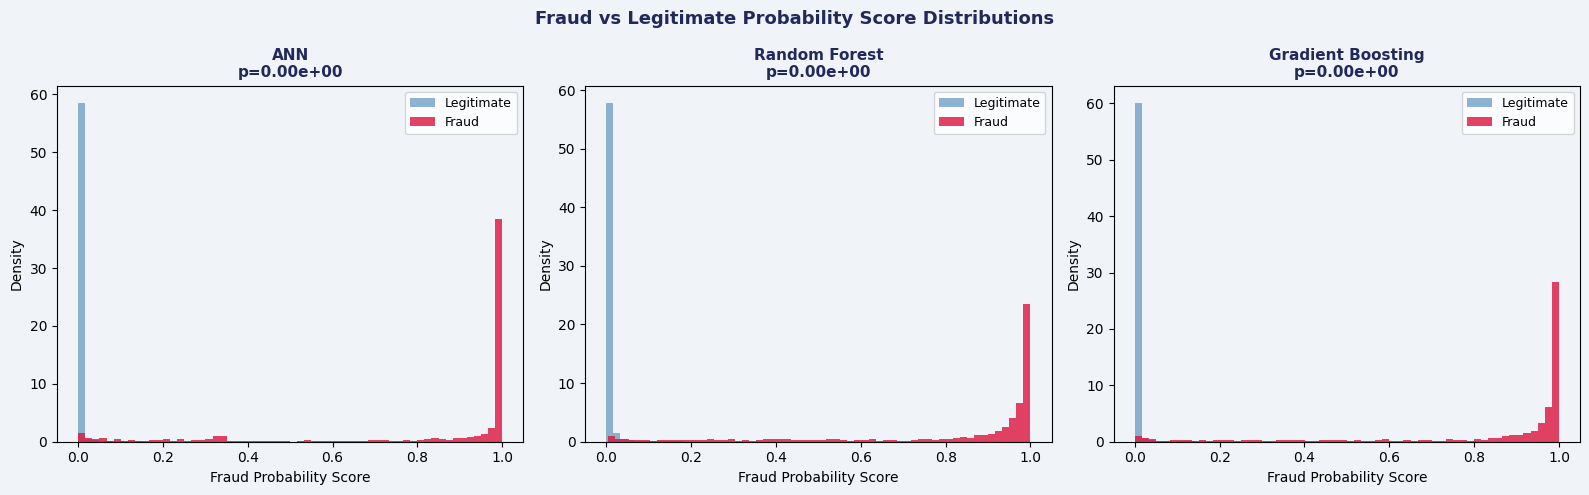


✅ Saved: output/two_sample_tests.png


In [80]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# All predictions and probabilities are already available
# ann_pred, rf_pred, gb_pred  → binary (0/1)
# ann_proba, rf_proba, gb_proba → probability scores
# y_test                      → true labels

α = 0.05

# ══════════════════════════════════════════════════════════════
# TEST 1 — McNEMAR'S TEST
# Compares two classifiers on the same test set
# Tests whether the disagreements between two models are symmetric
# H0: Both models make errors on the same transactions
# H1: One model is significantly better than the other
# ══════════════════════════════════════════════════════════════
print("=" * 62)
print("McNEMAR'S TEST — Pairwise Model Comparison")
print("H0: Both models have the same error pattern")
print("=" * 62)

def mcnemar_test(pred_a, pred_b, name_a, name_b, y_true):
    """
    Builds 2x2 contingency table:
        b00 = both correct
        b01 = A correct, B wrong
        b10 = A wrong,   B correct
        b11 = both wrong
    McNemar focuses on b01 and b10 (the disagreements)
    """
    correct_a = (pred_a == y_true.values)
    correct_b = (pred_b == y_true.values)

    b00 = np.sum( correct_a &  correct_b)   # both right
    b01 = np.sum( correct_a & ~correct_b)   # A right, B wrong
    b10 = np.sum(~correct_a &  correct_b)   # A wrong, B right
    b11 = np.sum(~correct_a & ~correct_b)   # both wrong

    table = [[b00, b01],
             [b10, b11]]

    result = mcnemar(table, exact=False, correction=True)

    sig = "✅ SIGNIFICANT" if result.pvalue < α else "❌ NOT SIGNIFICANT"
    print(f"\n{name_a}  vs  {name_b}")
    print(f"  Both correct:          {b00:>8,}")
    print(f"  {name_a} right, {name_b} wrong: {b01:>8,}")
    print(f"  {name_a} wrong, {name_b} right: {b10:>8,}")
    print(f"  Both wrong:            {b11:>8,}")
    print(f"  Chi² statistic: {result.statistic:.4f}")
    print(f"  p-value:        {result.pvalue:.6f}  →  {sig}")
    return result.pvalue

p_ann_rf = mcnemar_test(ann_pred, rf_pred, "ANN", "RF",  y_test)
p_ann_gb = mcnemar_test(ann_pred, gb_pred, "ANN", "GB",  y_test)
p_rf_gb  = mcnemar_test(rf_pred,  gb_pred, "RF",  "GB",  y_test)

# ══════════════════════════════════════════════════════════════
# TEST 2 — MANN-WHITNEY U TEST
# Compares fraud probability distributions: Fraud vs Not Fraud
# Non-parametric — no normality assumption needed
# H0: Fraud and legitimate transactions have same probability distribution
# H1: Fraud transactions receive significantly higher probability scores
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("MANN-WHITNEY U TEST — Fraud vs Legitimate Probability Scores")
print("H0: Fraud and legitimate score distributions are the same")
print("=" * 62)

def mw_test(proba, name, y_true):
    fraud_scores = proba[y_true.values == 1]
    legit_scores = proba[y_true.values == 0]

    stat, p = mannwhitneyu(fraud_scores, legit_scores,
                           alternative='greater')  # fraud scores > legit scores

    # Effect size — rank-biserial correlation
    n1, n2  = len(fraud_scores), len(legit_scores)
    effect  = 1 - (2 * stat) / (n1 * n2)

    sig = "✅ SIGNIFICANT" if p < α else "❌ NOT SIGNIFICANT"
    print(f"\n{name}")
    print(f"  Fraud scores   — mean: {fraud_scores.mean():.4f}  median: {np.median(fraud_scores):.4f}  n={n1:,}")
    print(f"  Legit scores   — mean: {legit_scores.mean():.4f}  median: {np.median(legit_scores):.4f}  n={n2:,}")
    print(f"  U statistic:  {stat:.2f}")
    print(f"  p-value:      {p:.2e}   →  {sig}")
    print(f"  Effect size (rank-biserial r): {effect:.4f}  {'(large)' if abs(effect)>0.5 else '(medium)' if abs(effect)>0.3 else '(small)'}")
    return p, effect

p_ann_mw, eff_ann = mw_test(ann_proba, "ANN",              y_test)
p_rf_mw,  eff_rf  = mw_test(rf_proba,  "Random Forest",    y_test)
p_gb_mw,  eff_gb  = mw_test(gb_proba,  "Gradient Boosting",y_test)

# ══════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("SUMMARY TABLE")
print("=" * 62)

summary = pd.DataFrame({
    "Test": [
        "McNemar: ANN vs RF",
        "McNemar: ANN vs GB",
        "McNemar: RF  vs GB",
        "Mann-Whitney: ANN (Fraud vs Legit)",
        "Mann-Whitney: RF  (Fraud vs Legit)",
        "Mann-Whitney: GB  (Fraud vs Legit)",
    ],
    "p-value": [
        f"{p_ann_rf:.6f}",
        f"{p_ann_gb:.6f}",
        f"{p_rf_gb:.6f}",
        f"{p_ann_mw:.2e}",
        f"{p_rf_mw:.2e}",
        f"{p_gb_mw:.2e}",
    ],
    "Significant (α=0.05)": [
        "Yes" if p_ann_rf < α else "No",
        "Yes" if p_ann_gb < α else "No",
        "Yes" if p_rf_gb  < α else "No",
        "Yes" if p_ann_mw < α else "No",
        "Yes" if p_rf_mw  < α else "No",
        "Yes" if p_gb_mw  < α else "No",
    ],
    "Interpretation": [
        "ANN and RF predict differently" if p_ann_rf < α else "ANN and RF agree on same errors",
        "ANN and GB predict differently" if p_ann_gb < α else "ANN and GB agree on same errors",
        "RF  and GB predict differently" if p_rf_gb  < α else "RF and GB agree on same errors",
        "ANN clearly separates fraud from legit" if p_ann_mw < α else "ANN scores overlap",
        "RF  clearly separates fraud from legit" if p_rf_mw  < α else "RF scores overlap",
        "GB  clearly separates fraud from legit" if p_gb_mw  < α else "GB scores overlap",
    ]
})
print(summary.to_string(index=False))

# ══════════════════════════════════════════════════════════════
# VISUALIZATION — Probability distributions
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#F0F4F8')
fig.suptitle('Fraud vs Legitimate Probability Score Distributions',
             fontsize=13, fontweight='bold', color='#21295c')

configs = [
    (ann_proba, "ANN",               "#1c77c3"),
    (rf_proba,  "Random Forest",     "#27ae60"),
    (gb_proba,  "Gradient Boosting", "#21295c"),
]

for ax, (proba, name, color) in zip(axes, configs):
    ax.set_facecolor('#F0F4F8')
    fraud_s = proba[y_test.values == 1]
    legit_s = proba[y_test.values == 0]
    ax.hist(legit_s, bins=60, alpha=0.6, color='steelblue',
            label='Legitimate', density=True)
    ax.hist(fraud_s, bins=60, alpha=0.8, color='crimson',
            label='Fraud', density=True)
    ax.set_title(f'{name}\np={p_ann_mw:.2e}' if name=="ANN"
            else f'{name}\np={p_rf_mw:.2e}' if "Forest" in name
            else f'{name}\np={p_gb_mw:.2e}',
            fontsize=11, fontweight='bold', color='#21295c')
    ax.set_xlabel('Fraud Probability Score', fontsize=10)
    ax.set_ylabel('Density',                 fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/two_sample_tests.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()